# Sales Data Analysis and Forecasting Dashboard

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [10]:
df = pd.read_csv("WalmartSalesData.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,05-01-2019,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,08-03-2019,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,27-01-2019,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,08-02-2019,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [11]:
df.shape

(1000, 17)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [13]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [14]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [15]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [16]:
df[['Date']].head()

,Date
0,2019-01-05
1,2019-03-08
2,2019-03-03
3,2019-01-27
4,2019-02-08


In [17]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [18]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

In [19]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Day,Year,Hour
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,1,5,2019,13
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,10:29:00,Cash,76.40,4.761905,3.8200,9.6,3,8,2019,10
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,3,3,2019,13
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,1,27,2019,20
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2,8,2019,10


In [20]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [21]:
# Daily Sales
daily_sales = df.groupby('Date')['Total'].sum().reset_index()

In [22]:
daily_sales.head()

,Date,Total
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


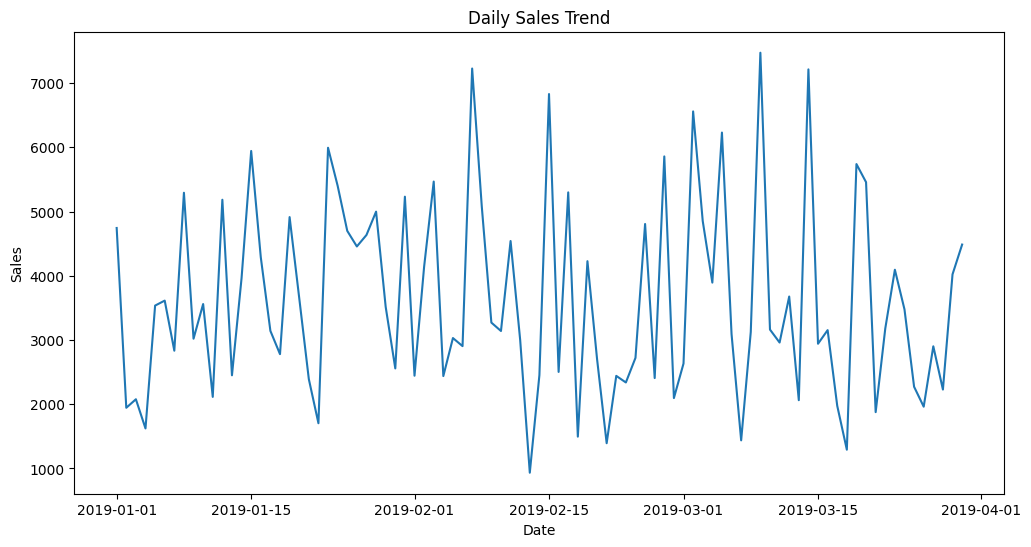

In [23]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales['Date'], daily_sales['Total'])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [24]:
daily_sales.to_csv("DailySales.csv", index=False)

In [25]:
# load DailySales.csv to system
from google.colab import files
files.download("DailySales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

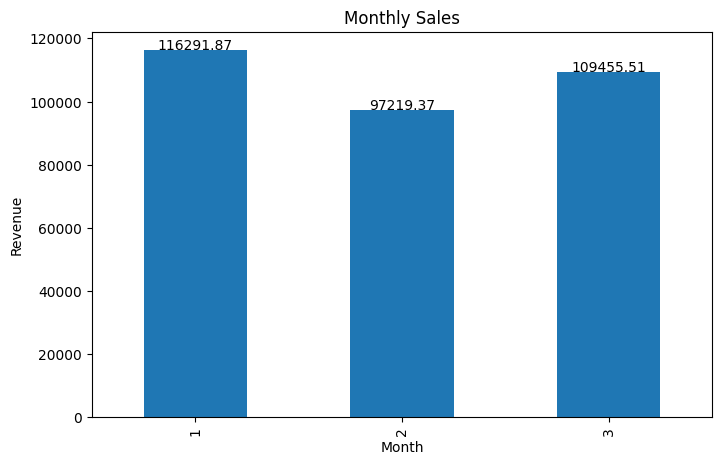

In [26]:
#Monthly Sales Trend
monthly_sales = df.groupby('Month')['Total'].sum()

plt.figure(figsize=(8,5))

ax = monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Add labels
for i, v in enumerate(monthly_sales):
    ax.text(i, v + 100, str(round(v,2)), ha='center')

plt.show()

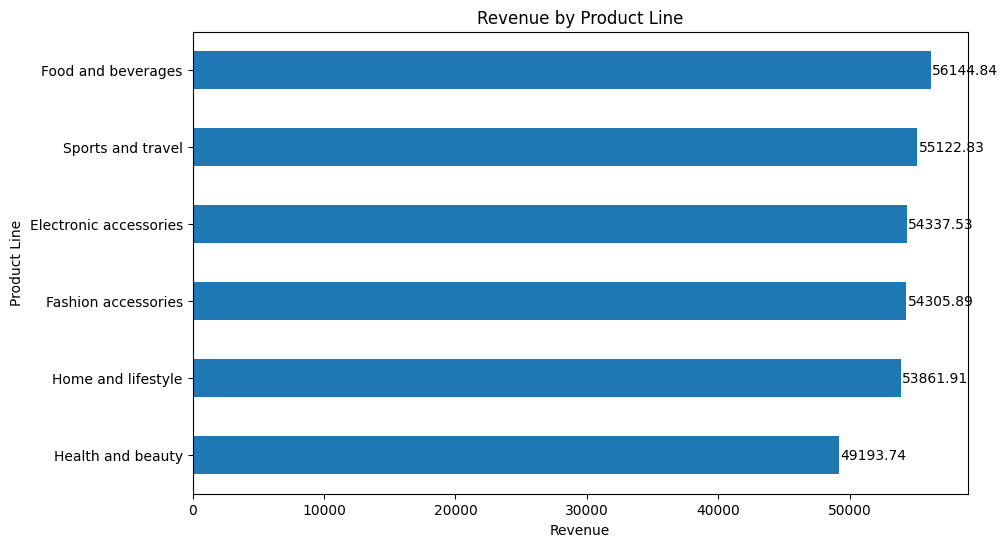

In [28]:
#Product Line Analysis
product_sales = df.groupby('Product line')['Total'].sum()

plt.figure(figsize=(10,6))

ax = product_sales.sort_values().plot(kind='barh')

plt.title("Revenue by Product Line")
plt.xlabel("Revenue")
plt.ylabel("Product Line")

# Add labels
for i, v in enumerate(product_sales.sort_values()):
    ax.text(v + 100, i, str(round(v,2)), va='center')

plt.show()

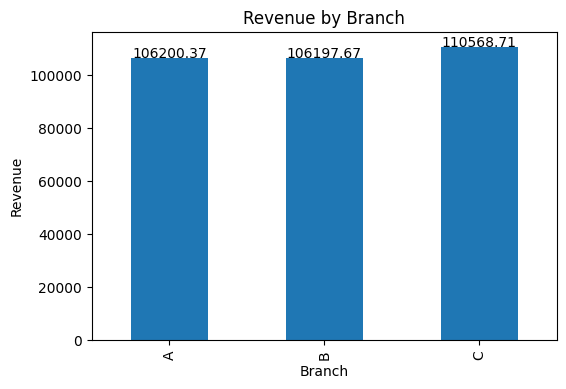

In [29]:
#Branch sales
branch_sales = df.groupby('Branch')['Total'].sum()

plt.figure(figsize=(6,4))

ax = branch_sales.plot(kind='bar')

plt.title("Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Revenue")

# Add labels
for i, v in enumerate(branch_sales):
    ax.text(i, v + 100, str(round(v,2)), ha='center')

plt.show()

##Forecasting Model

In [30]:
daily_sales.head()

,Date,Total
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


In [31]:
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

daily_sales.set_index('Date', inplace=True)

daily_sales.head()

,Total
Date,
2019-01-01,4745.1810
2019-01-02,1945.5030
2019-01-03,2078.1285
2019-01-04,1623.6885
2019-01-05,3536.6835


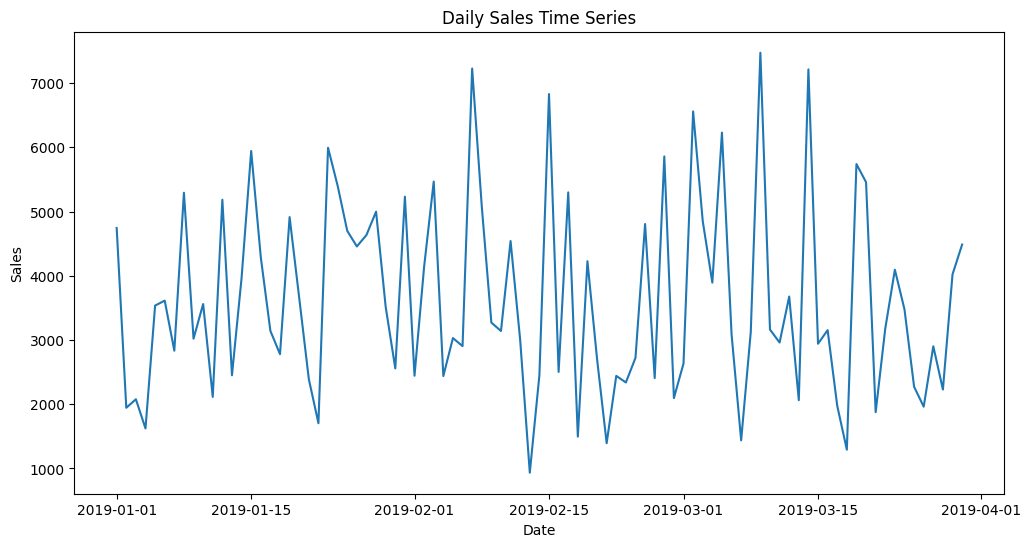

In [32]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales.index, daily_sales['Total'])

plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [33]:
train_size = int(len(daily_sales) * 0.8)

train = daily_sales[:train_size]

test = daily_sales[train_size:]

In [34]:
print(len(train))
print(len(test))

71
18


In [35]:
!pip install statsmodels

In [36]:
from statsmodels.tsa.arima.model import ARIMA

In [56]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Total'], order=(5,1,2))

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

In [58]:
predictions = model_fit.forecast(steps=len(test))

In [59]:
predictions.head()

,predicted_mean
2019-03-13,4307.957200
2019-03-14,3516.144522
2019-03-15,3539.110744
2019-03-16,3686.652007
2019-03-17,3781.666682


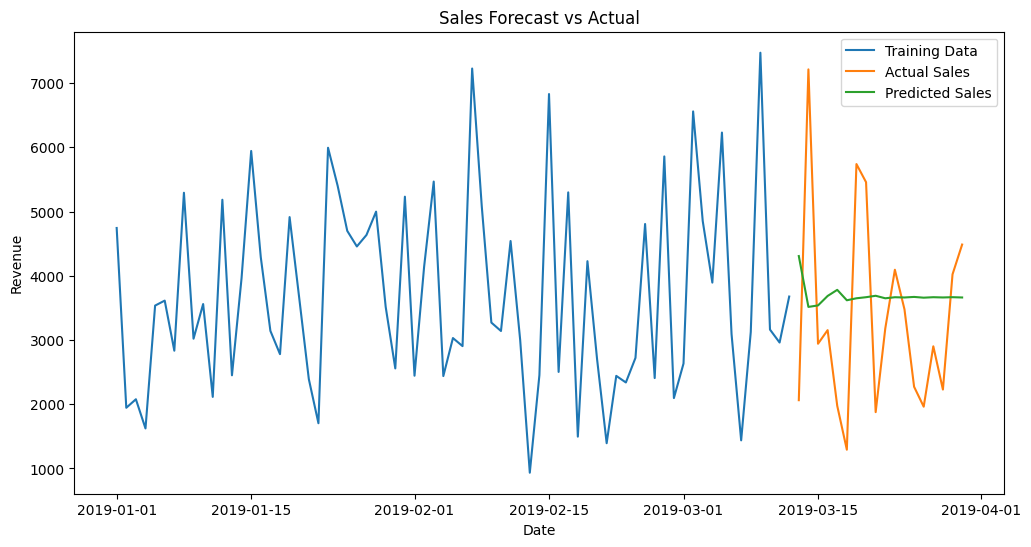

In [50]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Total'], label='Training Data')

plt.plot(test.index, test['Total'], label='Actual Sales')

plt.plot(test.index, predictions, label='Predicted Sales')

plt.legend()

plt.title("Sales Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [51]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [52]:
mae = mean_absolute_error(test['Total'], predictions)

rmse = np.sqrt(mean_squared_error(test['Total'], predictions))

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 1358.6556184432136
RMSE: 1626.3289762557972


MAE represents the average prediction error, while RMSE penalizes large errors more strongly. Lower values indicate better forecasting performance.

In [53]:
future_forecast = model_fit.forecast(steps=30)

In [54]:
future_forecast

,predicted_mean
2019-03-13,4307.957200
2019-03-14,3516.144522
2019-03-15,3539.110744
2019-03-16,3686.652007
2019-03-17,3781.666682
2019-03-18,3619.423488
2019-03-19,3650.568739
2019-03-20,3667.270301
2019-03-21,3689.558897
2019-03-22,3650.363545


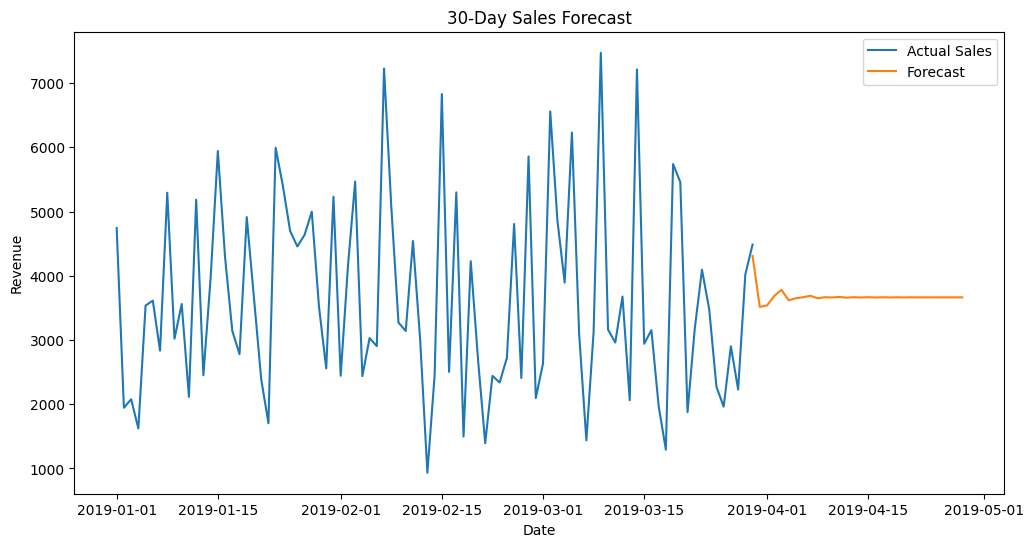

In [55]:
future_forecast = model_fit.forecast(steps=30)

future_dates = pd.date_range(
    start=daily_sales.index[-1],
    periods=30,
    freq='D'
)

plt.figure(figsize=(12,6))

plt.plot(daily_sales.index, daily_sales['Total'], label='Actual Sales')

plt.plot(future_dates, future_forecast, label='Forecast')

plt.legend()

plt.title("30-Day Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [60]:
forecast_df = pd.DataFrame()

forecast_df['Date'] = future_dates

forecast_df['Forecast_Sales'] = future_forecast.values

In [61]:
forecast_df.to_csv("FinalSalesForecast.csv", index=False)

In [62]:
forecast_df.head()

,Date,Forecast_Sales
0,2019-03-30,4307.957200
1,2019-03-31,3516.144522
2,2019-04-01,3539.110744
3,2019-04-02,3686.652007
4,2019-04-03,3781.666682


In [63]:
from google.colab import files
files.download("FinalSalesForecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
from sklearn.linear_model import LinearRegression

In [65]:
daily_sales_lr = daily_sales.reset_index()

daily_sales_lr['DayNumber'] = range(len(daily_sales_lr))

In [66]:
daily_sales_lr.head()

,Date,Total,DayNumber
0,2019-01-01,4745.1810,0
1,2019-01-02,1945.5030,1
2,2019-01-03,2078.1285,2
3,2019-01-04,1623.6885,3
4,2019-01-05,3536.6835,4


In [67]:
train_lr = daily_sales_lr[:train_size]
test_lr = daily_sales_lr[train_size:]

In [69]:
model_lr = LinearRegression()

model_lr.fit(
    train_lr[['DayNumber']],
    train_lr['Total']
)

LinearRegression()

In [70]:
pred_lr = model_lr.predict(test_lr[['DayNumber']])

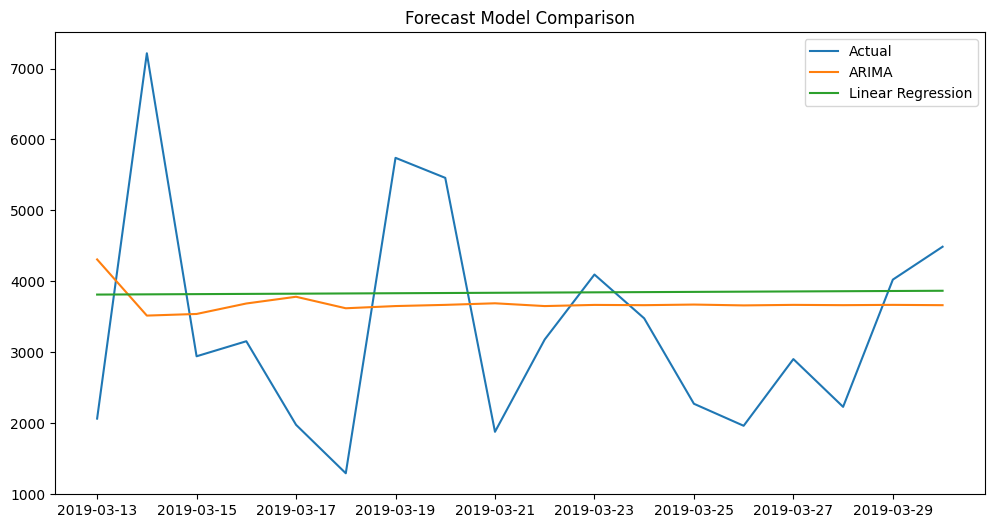

In [71]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Total'], label='Actual')

plt.plot(test.index, predictions, label='ARIMA')

plt.plot(test.index, pred_lr, label='Linear Regression')

plt.legend()

plt.title("Forecast Model Comparison")

plt.show()

In [72]:
mae_arima = mean_absolute_error(test['Total'], predictions)

rmse_arima = np.sqrt(mean_squared_error(test['Total'], predictions))

mae_lr = mean_absolute_error(test['Total'], pred_lr)

rmse_lr = np.sqrt(mean_squared_error(test['Total'], pred_lr))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

print("LR MAE:", mae_lr)
print("LR RMSE:", rmse_lr)

ARIMA MAE: 1358.6556184432136
ARIMA RMSE: 1626.3289762557972
LR MAE: 1371.3973524061032
LR RMSE: 1606.8564836846492


I implemented both ARIMA and Linear Regression models and compared their prediction errors. ARIMA performed better because it captures time dependencies in the data.